In [1]:
# ==========================================================
# 0. Imports & Configuration
# ==========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.utils import to_categorical

from collections import Counter

In [2]:
# ==========================================================
# 1. Data Loading & Metadata Merge
# ==========================================================
# 1.1 Download and define paths
import kagglehub
path = kagglehub.dataset_download("malekzadeh/motionsense-dataset")
main_dir      = os.path.join(path, "A_DeviceMotion_data", "A_DeviceMotion_data")
subjects_path = os.path.join(path, "data_subjects_info.csv")

# 1.2 Load subject metadata
subjects = pd.read_csv(subjects_path)

# 1.3 Read and annotate sensor CSVs
data = {}
for subdir in os.listdir(main_dir):
    sd_path = os.path.join(main_dir, subdir)
    if not os.path.isdir(sd_path): continue
    frames = []
    for fn in os.listdir(sd_path):
        if fn.endswith(".csv"):
            df = pd.read_csv(os.path.join(sd_path, fn))
            # add gender & class
            idx = len(frames)
            df['gender']  = subjects.iloc[idx]['gender']
            df['class']   = subdir.split('_')[0]
            # add weight, height, age, subject ID
            df.insert(len(df.columns)-2, 'weight',  subjects.iloc[idx]['weight'])
            df.insert(len(df.columns)-1, 'height',  subjects.iloc[idx]['height'])
            df.insert(len(df.columns),   'age',     subjects.iloc[idx]['age'])
            df.insert(len(df.columns),   'subject', subjects.iloc[idx]['code'])
            frames.append(df)
    data[subdir] = frames

# 1.4 Combine into final_df
all_dfs = [pd.concat(frames, ignore_index=True) for frames in data.values()]
final_df = pd.concat(all_dfs, ignore_index=True)
print("✅ Final DataFrame shape:", final_df.shape)



100%|██████████| 72.0M/72.0M [00:00<00:00, 157MB/s]

Extracting files...


✅ Final DataFrame shape: (1412865, 19)


In [4]:
final_df = final_df.drop(columns=["Unnamed: 0"])

In [3]:
# ==========================================================
# 2. Preprocessing & Segmentation
# ==========================================================
# -----------------------------
# Global parameters
# -----------------------------
SAMPLING_HZ  = 50          # dataset rate (Hz)
WIN_SIZE     = 128         # 2.56 s window
WIN_STRIDE   = 64          # 50 % overlap
LP_ORDER     = 4           # Butterworth order
LP_CUTOFF_HZ = 20          # low‑pass cut‑off


# 2.1 Define sensor columns
meta_cols   = ['weight','height','age','gender','subject','class']
sensor_cols = [c for c in final_df.columns if c not in meta_cols]

# 2.2 Butterworth low-pass filter
def butter_lowpass(arr, fs=SAMPLING_HZ, cutoff=LP_CUTOFF_HZ, order=LP_ORDER):
    b, a = butter(order, cutoff/(0.5*fs), btype='low')
    return filtfilt(b, a, arr, axis=0)

final_df[sensor_cols] = butter_lowpass(final_df[sensor_cols].values)

# 2.3 Subject-independent split
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(final_df, groups=final_df['subject']))
train_df = final_df.iloc[np.sort(train_idx)].reset_index(drop=True)
test_df  = final_df.iloc[np.sort(test_idx)].reset_index(drop=True)
print("Subjects → train:", train_df['subject'].nunique(), "| test:", test_df['subject'].nunique())

# 2.4 Z-score normalization (fit on train only)
scaler = StandardScaler().fit(train_df[sensor_cols])
train_df[sensor_cols] = scaler.transform(train_df[sensor_cols])
test_df[sensor_cols]  = scaler.transform(test_df[sensor_cols])

# 2.5 Overlapping window segmentation
def create_windows(df, win=WIN_SIZE, stride=WIN_STRIDE):
    X, y = [], []
    for subj, subdf in df.groupby('subject'):
        subdf = subdf.reset_index(drop=True)
        for start in range(0, len(subdf)-win+1, stride):
            sl = subdf.iloc[start:start+win]
            lbl, cnt = Counter(sl['class']).most_common(1)[0]
            if cnt / win >= 0.80:
                X.append(sl[sensor_cols].values)
                y.append(lbl)
    return np.array(X), np.array(y)

X_train, y_train = create_windows(train_df)
X_test,  y_test  = create_windows(test_df)
print(f"Window shapes → X_train: {X_train.shape}, y_train: {y_train.shape} || X_test: {X_test.shape}, y_test: {y_test.shape}")


Subjects → train: 19 | test: 5
Window shapes → X_train: (17196, 128, 13), y_train: (17196,) || X_test: (4532, 128, 13), y_test: (4532,)


In [7]:
# ==========================================================
# 3. Feature Engineering & Label Encoding
# ==========================================================
# 3.1 Hand-crafted feature extraction
def extract_features(X):
    feats = []
    for w in X:
        feats.append(np.hstack([w.mean(0), w.std(0), w.min(0), w.max(0)]))
    return np.array(feats)

X_train_feat = extract_features(X_train)
X_test_feat  = extract_features(X_test)
print("Feature shapes →", X_train_feat.shape, X_test_feat.shape)

# 3.2 Label encoding & one-hot
le = LabelEncoder().fit(y_train)
y_train_int = le.transform(y_train)
y_test_int  = le.transform(y_test)
n_classes   = len(le.classes_)
y_train_oh  = to_categorical(y_train_int, num_classes=n_classes)
y_test_oh   = to_categorical(y_test_int,  num_classes=n_classes)
print("Classes:", le.classes_)


Feature shapes → (16898, 48) (4768, 48)
Classes: ['dws' 'jog' 'sit' 'std' 'ups' 'wlk']


RF Accuracy: 0.904
SVM Accuracy: 0.889

=== Random Forest Report ===
              precision    recall  f1-score   support

         dws       0.59      0.91      0.71       398
         jog       0.96      0.93      0.94       433
         sit       0.98      1.00      0.99      1163
         std       0.99      0.97      0.98      1139
         ups       0.94      0.70      0.81       498
         wlk       0.87      0.81      0.84      1137

    accuracy                           0.90      4768
   macro avg       0.89      0.89      0.88      4768
weighted avg       0.92      0.90      0.91      4768



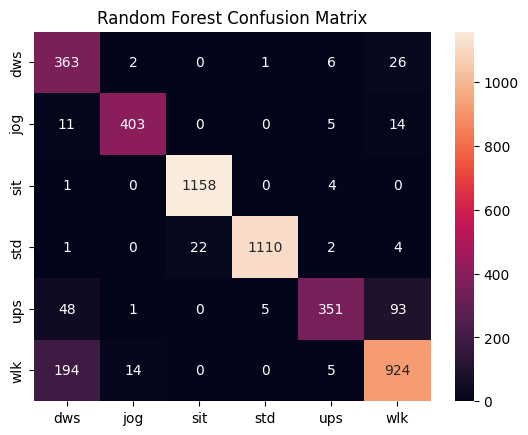


=== SVM Report ===
              precision    recall  f1-score   support

         dws       0.52      0.87      0.65       398
         jog       0.92      0.90      0.91       433
         sit       1.00      0.99      1.00      1163
         std       0.98      1.00      0.99      1139
         ups       0.85      0.74      0.79       498
         wlk       0.90      0.74      0.81      1137

    accuracy                           0.89      4768
   macro avg       0.86      0.87      0.86      4768
weighted avg       0.91      0.89      0.89      4768



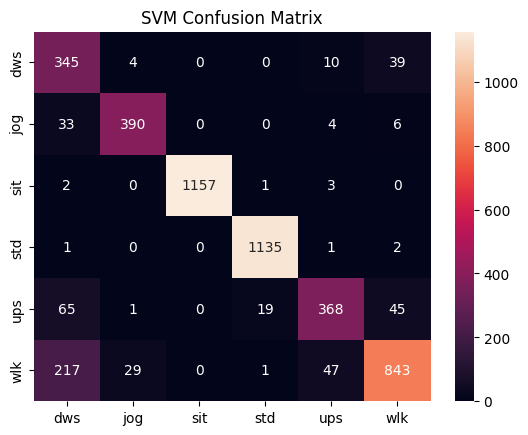

In [9]:
# ==========================================================
# 4. Classical ML Models
# ==========================================================
# 4.1 Random Forest
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train_feat, y_train_int)
y_rf = rf.predict(X_test_feat)
# Use f-string formatting to display the accuracy rounded to 3 decimal places
print(f"RF Accuracy: {accuracy_score(y_test_int, y_rf):.3f}")

# 4.2 SVM
svm_pipe = Pipeline([('sc', StandardScaler()), ('svm', SVC(C=10, kernel='rbf', class_weight='balanced'))])
svm_pipe.fit(X_train_feat, y_train_int)
y_svm = svm_pipe.predict(X_test_feat)
# Use f-string formatting to display the accuracy rounded to 3 decimal places
print(f"SVM Accuracy: {accuracy_score(y_test_int, y_svm):.3f}")

# 4.3 Reports
for name, y_pred in [("Random Forest", y_rf), ("SVM", y_svm)]:
    print(f"\n=== {name} Report ===")
    print(classification_report(y_test_int, y_pred, target_names=le.classes_))
    cm = confusion_matrix(y_test_int, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(name + " Confusion Matrix"); plt.show()

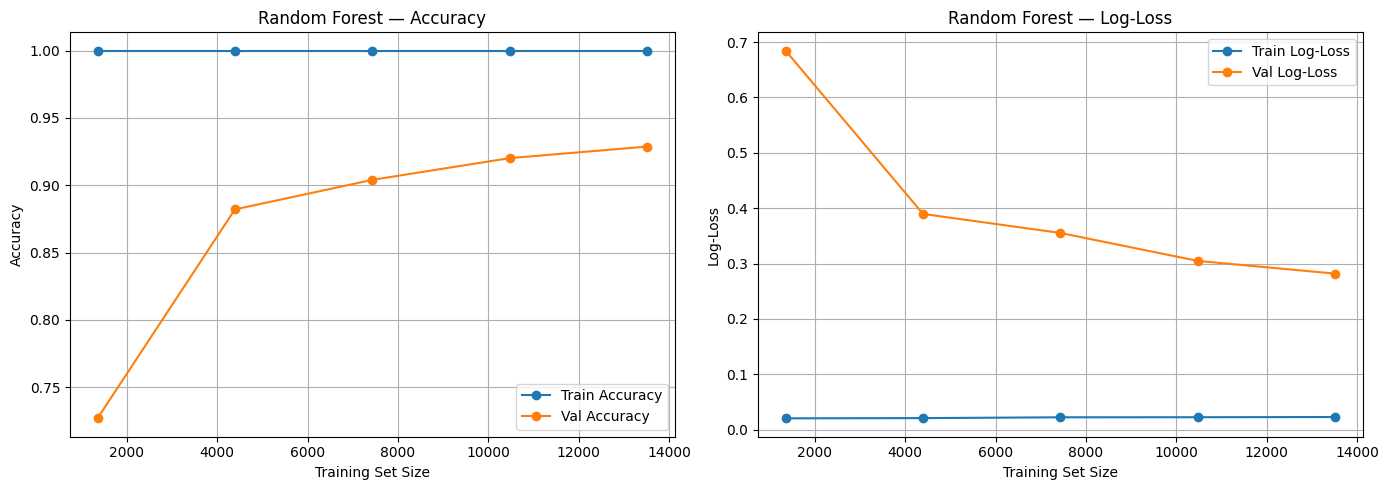

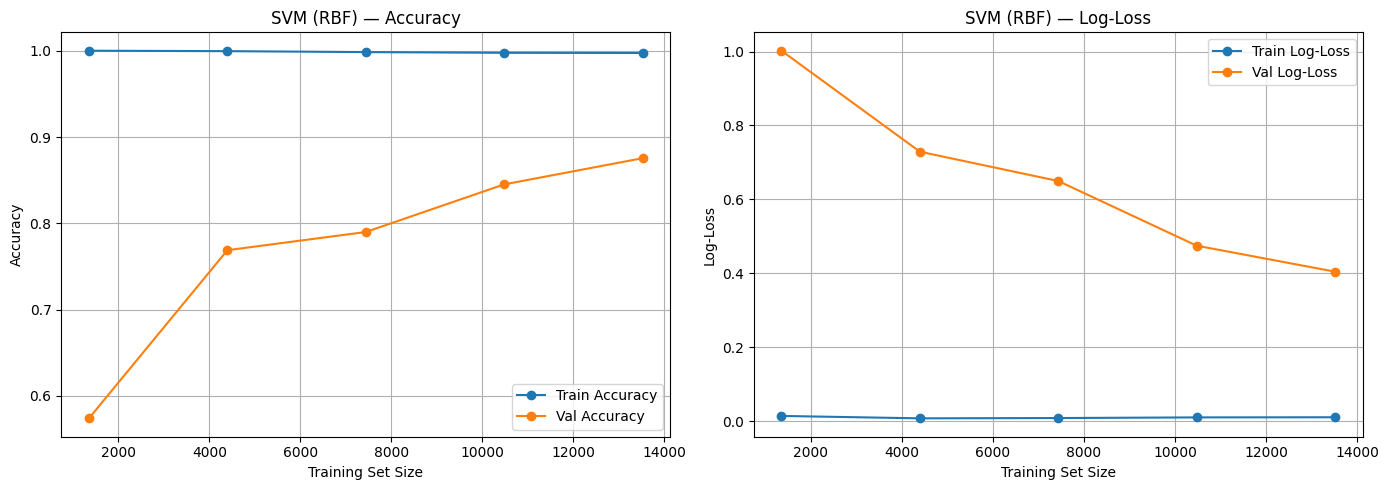

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_ml_learning_curve(estimator, X, y, title):
    """
    Plots training & validation curves for accuracy and log-loss.
    """
    train_sizes = np.linspace(0.1, 1.0, 5)

    # Accuracy curves
    train_sizes_, train_acc, val_acc = learning_curve(
        estimator, X, y,
        train_sizes=train_sizes,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    # Log-loss curves (sklearn returns negative log-loss, so we invert)
    train_sizes__, train_loss_neg, val_loss_neg = learning_curve(
        estimator, X, y,
        train_sizes=train_sizes,
        cv=5,
        scoring='neg_log_loss',
        n_jobs=-1
    )

    train_loss = -train_loss_neg
    val_loss   = -val_loss_neg

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    axes[0].plot(train_sizes_, np.mean(train_acc, axis=1), 'o-', color='tab:blue', label='Train Accuracy')
    axes[0].plot(train_sizes_, np.mean(val_acc,   axis=1), 'o-', color='tab:orange', label='Val Accuracy')
    axes[0].set_title(f"{title} — Accuracy")
    axes[0].set_xlabel("Training Set Size")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    # Log-loss plot
    axes[1].plot(train_sizes__, np.mean(train_loss, axis=1), 'o-', color='tab:blue', label='Train Log-Loss')
    axes[1].plot(train_sizes__, np.mean(val_loss,   axis=1), 'o-', color='tab:orange', label='Val Log-Loss')
    axes[1].set_title(f"{title} — Log-Loss")
    axes[1].set_xlabel("Training Set Size")
    axes[1].set_ylabel("Log-Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


# Make sure SVM pipeline has probability=True for log-loss
# Changed svm_pipeline to svm_pipe
svm_pipe.set_params(svm__probability=True)

# Plot for Random Forest
plot_ml_learning_curve(rf,         X_train_feat, y_train_int, "Random Forest")

# Plot for SVM (RBF)
# Changed svm_pipeline to svm_pipe
plot_ml_learning_curve(svm_pipe, X_train_feat, y_train_int, "SVM (RBF)")

In [12]:
# ==========================================================
# 5. Deep Learning Models
# ==========================================================
# 5.1 Helpers
def compile_and_train(model, X, y, name, batch=128, epochs=100, patience=10):
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    es = callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    rl = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
    history = model.fit(X, y, epochs=epochs, batch_size=batch, validation_split=0.1, callbacks=[es, rl], verbose=2)
    return history

def plot_history(hist, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist.history['accuracy'], label='Train')
    plt.plot(hist.history['val_accuracy'], label='Val')
    plt.title(f"{title} Accuracy"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(hist.history['loss'], label='Train')
    plt.plot(hist.history['val_loss'], label='Val')
    plt.title(f"{title} Loss"); plt.legend()
    plt.tight_layout(); plt.show()

def build_cnn():
    m = models.Sequential([
        layers.Input((WIN_SIZE, len(sensor_cols))),
        layers.Conv1D(128,5,padding='same'), layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling1D(2),
        layers.Conv1D(256,5,padding='same'), layers.BatchNormalization(), layers.ReLU(),
        layers.GlobalAveragePooling1D(), layers.Dropout(0.4),
        layers.Dense(n_classes, activation='softmax')
    ])
    return m

def build_cnn_lstm():
    inp = layers.Input((WIN_SIZE, len(sensor_cols)))
    x = layers.Conv1D(64,5,padding='same')(inp); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128,5,padding='same')(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Bidirectional(layers.LSTM(128))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return models.Model(inp, out)

Epoch 1/100
119/119 - 40s - 333ms/step - accuracy: 0.9063 - loss: 0.3080 - val_accuracy: 0.7746 - val_loss: 0.6290 - learning_rate: 1.0000e-03
Epoch 2/100
119/119 - 41s - 342ms/step - accuracy: 0.9724 - loss: 0.1168 - val_accuracy: 0.8349 - val_loss: 0.5154 - learning_rate: 1.0000e-03
Epoch 3/100
119/119 - 38s - 321ms/step - accuracy: 0.9783 - loss: 0.0869 - val_accuracy: 0.7686 - val_loss: 0.9196 - learning_rate: 1.0000e-03
Epoch 4/100
119/119 - 39s - 329ms/step - accuracy: 0.9806 - loss: 0.0724 - val_accuracy: 0.8012 - val_loss: 0.6325 - learning_rate: 1.0000e-03
Epoch 5/100
119/119 - 36s - 301ms/step - accuracy: 0.9813 - loss: 0.0649 - val_accuracy: 0.9065 - val_loss: 0.5828 - learning_rate: 1.0000e-03
Epoch 6/100
119/119 - 35s - 297ms/step - accuracy: 0.9836 - loss: 0.0565 - val_accuracy: 0.8775 - val_loss: 0.7335 - learning_rate: 1.0000e-03
Epoch 7/100
119/119 - 40s - 339ms/step - accuracy: 0.9878 - loss: 0.0434 - val_accuracy: 0.8213 - val_loss: 0.8329 - learning_rate: 5.0000e-04

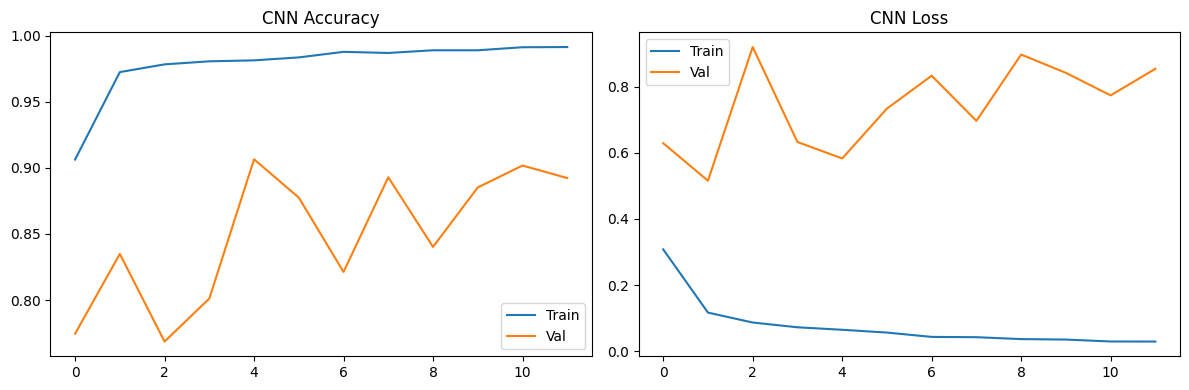

CNN Test Acc: 0.918
Epoch 1/100
119/119 - 45s - 380ms/step - accuracy: 0.9147 - loss: 0.2590 - val_accuracy: 0.7272 - val_loss: 1.0630 - learning_rate: 1.0000e-03
Epoch 2/100
119/119 - 38s - 321ms/step - accuracy: 0.9780 - loss: 0.0765 - val_accuracy: 0.9178 - val_loss: 0.3671 - learning_rate: 1.0000e-03
Epoch 3/100
119/119 - 42s - 354ms/step - accuracy: 0.9800 - loss: 0.0641 - val_accuracy: 0.9095 - val_loss: 0.3915 - learning_rate: 1.0000e-03
Epoch 4/100
119/119 - 40s - 335ms/step - accuracy: 0.9842 - loss: 0.0487 - val_accuracy: 0.8923 - val_loss: 0.3163 - learning_rate: 1.0000e-03
Epoch 5/100
119/119 - 42s - 353ms/step - accuracy: 0.9904 - loss: 0.0339 - val_accuracy: 0.9136 - val_loss: 0.2640 - learning_rate: 1.0000e-03
Epoch 6/100
119/119 - 40s - 332ms/step - accuracy: 0.9899 - loss: 0.0303 - val_accuracy: 0.8414 - val_loss: 0.5033 - learning_rate: 1.0000e-03
Epoch 7/100
119/119 - 41s - 346ms/step - accuracy: 0.9901 - loss: 0.0287 - val_accuracy: 0.8970 - val_loss: 0.3364 - learn

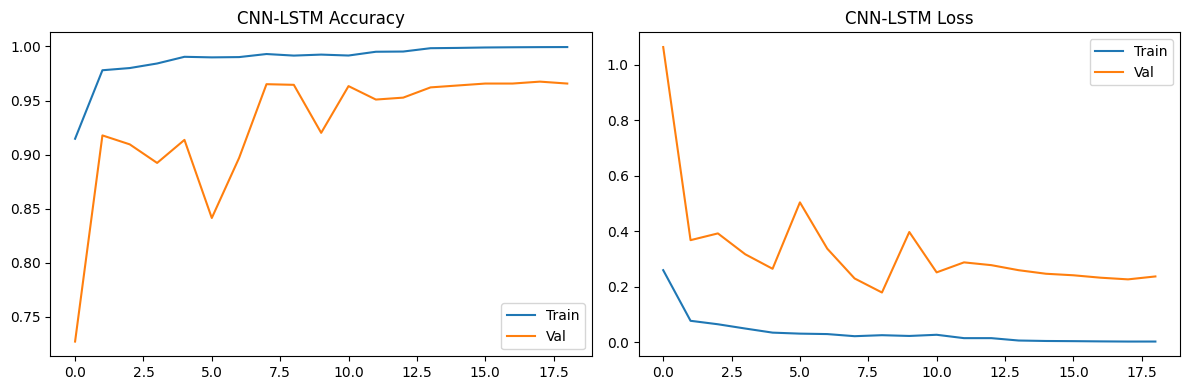

CNN-LSTM Test Acc: 0.943


In [14]:
# 5.2 Train & evaluate CNN
cnn = build_cnn()
hist_cnn = compile_and_train(cnn, X_train, y_train_oh, "CNN")
plot_history(hist_cnn, "CNN")
_, acc_cnn = cnn.evaluate(X_test, y_test_oh, verbose=0)
print(f"CNN Test Acc: {acc_cnn:.3f}")

# 5.3 Train & evaluate CNN-LSTM
cnn_lstm = build_cnn_lstm()
hist_lstm = compile_and_train(cnn_lstm, X_train, y_train_oh, "CNN-LSTM")
plot_history(hist_lstm, "CNN-LSTM")
_, acc_lstm = cnn_lstm.evaluate(X_test, y_test_oh, verbose=0)
print(f"CNN-LSTM Test Acc: {acc_lstm:.3f}")

In [ ]:
# ------------------------------------------------------------
# 5.4 CNN → Transformer Encoder
# ------------------------------------------------------------
def build_cnn_transformer(n_steps=WIN_SIZE, n_feats=len(sensor_cols),
                          n_classes=n_classes, n_heads=4, d_model=128, d_ff=256, n_blocks=2):
    inp = layers.Input(shape=(n_steps, n_feats))
    # CNN front-end
    x = layers.Conv1D(d_model, 3, padding='same')(inp)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    # Positional encoding (learnable embeddings)
    positions = tf.range(start=0, limit=n_steps, delta=1)
    pos_embed = layers.Embedding(input_dim=n_steps, output_dim=d_model)(positions)
    x = x + pos_embed
    # Transformer blocks
    for _ in range(n_blocks):
        attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model)(x, x)
        x = layers.Add()([x, attn])
        x = layers.LayerNormalization()(x)
        ff = layers.Dense(d_ff, activation='relu')(x)
        ff = layers.Dense(d_model)(ff)
        x = layers.Add()([x, ff])
        x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return models.Model(inp, out)

cnn_trans = build_cnn_transformer()
hist_trans = compile_and_train(cnn_trans, X_train, y_train_oh, "CNN-Transformer")
plot_history(hist_trans, "CNN-Transformer")
_, acc_trans = cnn_trans.evaluate(X_test, y_test_oh, verbose=0)
print(f"CNN-Transformer Test Acc: {acc_trans:.3f}")

In [15]:
# ==========================================================
# 6. Classification Reports for Deep Models
# ==========================================================
from sklearn.metrics import classification_report, confusion_matrix

def deep_classification_report(model, X, y_true_oh, y_true_int, title):
    # Predict probabilities and convert to integer labels
    y_pred_probs = model.predict(X, verbose=0)
    y_pred_int   = y_pred_probs.argmax(axis=1)

    # Print classification report
    print(f"\n=== {title} Classification Report ===")
    print(classification_report(
        y_true_int,
        y_pred_int,
        target_names=le.classes_,
        digits=3
    ))

    # Confusion matrix plot
    cm = confusion_matrix(y_true_int, y_pred_int)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{title} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()



=== CNN Classification Report ===
              precision    recall  f1-score   support

         dws      0.884     0.553     0.680       398
         jog      0.965     0.949     0.957       433
         sit      0.999     0.998     0.999      1163
         std      0.905     1.000     0.950      1139
         ups      0.750     0.801     0.775       498
         wlk      0.919     0.923     0.921      1137

    accuracy                          0.918      4768
   macro avg      0.904     0.871     0.880      4768
weighted avg      0.919     0.918     0.915      4768



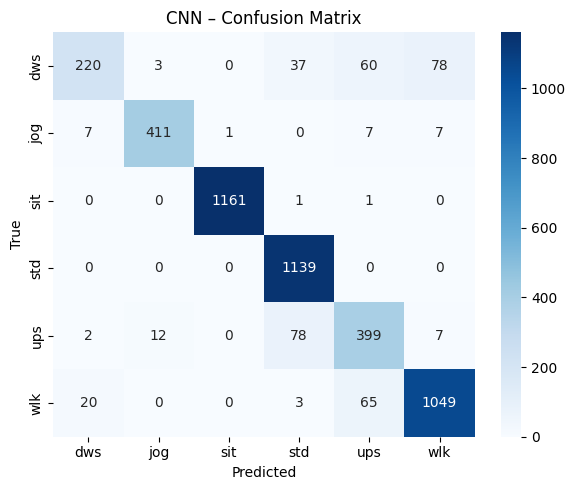


=== CNN-LSTM Classification Report ===
              precision    recall  f1-score   support

         dws      0.877     0.789     0.831       398
         jog      0.881     0.958     0.918       433
         sit      1.000     0.997     0.998      1163
         std      0.971     0.993     0.982      1139
         ups      0.971     0.735     0.837       498
         wlk      0.896     0.975     0.934      1137

    accuracy                          0.943      4768
   macro avg      0.933     0.908     0.917      4768
weighted avg      0.944     0.943     0.941      4768



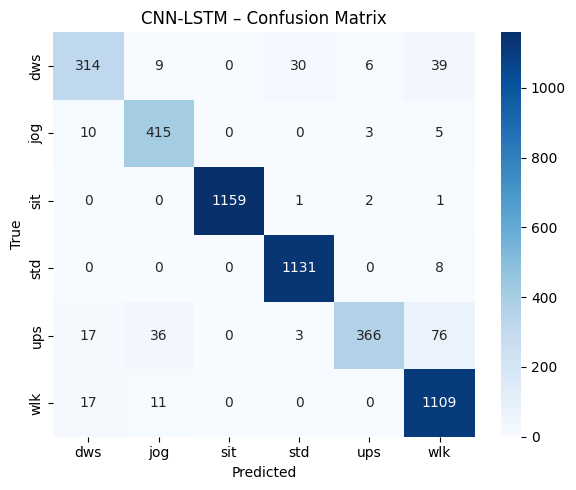

In [16]:
# Generate reports for each model
deep_classification_report(cnn,       X_test, y_test_oh, y_test_int, "CNN")
deep_classification_report(cnn_lstm,  X_test, y_test_oh, y_test_int, "CNN-LSTM")

In [ ]:
deep_classification_report(cnn_trans, X_test, y_test_oh, y_test_int, "CNN-Transformer")